In [19]:
import json
import os

# Define the file paths
dataset_files = [
    "./519_questions_from_all_methods/baseline_score.jsonl", 
    "./519_questions_from_all_methods/ragas_hallucination_results.jsonl", 
    "./519_questions_from_all_methods/selfcheck_dataset.jsonl",
    "./519_questions_from_all_methods/similarity_dataset.jsonl"
]
human_labelled_data = "./balanced_experiment_dataset-human-label.jsonl"
output_folder = "./150_filtered"

def filter_datasets():
    # Create the output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Step 1: Extract all valid IDs from the human-labeled dataset
    allowed_ids = set()
    
    print("Reading human-labeled data...")
    with open(human_labelled_data, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                if 'id' in obj:
                    allowed_ids.add(obj['id'])
                
    print(f"Found {len(allowed_ids)} unique IDs to match against.\n")

    # Step 2: Filter each dataset file
    for file_path in dataset_files:
        if not os.path.exists(file_path):
            print(f"Skipping: {file_path} (File not found)")
            continue
            
        base_name = os.path.basename(file_path)
        name, ext = os.path.splitext(base_name)
        
        # Save all filtered files inside the '150_filtered' directory
        output_path = os.path.join(output_folder, f"{name}_filtered{ext}")
        
        # Determine which ID key to look for based on the file name
        id_key = 'original_id' if base_name == "ragas_hallucination_results.jsonl" else 'id'
        
        match_count = 0
        total_count = 0
        
        print(f"Filtering {base_name} using key '{id_key}'...")
        with open(file_path, 'r', encoding='utf-8') as infile, \
             open(output_path, 'w', encoding='utf-8') as outfile:
                 
            for line in infile:
                if not line.strip():
                    continue
                total_count += 1
                obj = json.loads(line)
                
                # Check if the designated ID key exists and matches our allowed set
                if id_key in obj and obj[id_key] in allowed_ids:
                    outfile.write(json.dumps(obj) + '\n')
                    match_count += 1
                    
        print(f"Saved {match_count}/{total_count} matching objects to {output_path}\n")

if __name__ == "__main__":
    filter_datasets()

Reading human-labeled data...
Found 150 unique IDs to match against.

Filtering baseline_score.jsonl using key 'id'...
Saved 149/518 matching objects to ./150_filtered/baseline_score_filtered.jsonl

Filtering ragas_hallucination_results.jsonl using key 'original_id'...
Saved 150/519 matching objects to ./150_filtered/ragas_hallucination_results_filtered.jsonl

Filtering selfcheck_dataset.jsonl using key 'id'...
Saved 150/519 matching objects to ./150_filtered/selfcheck_dataset_filtered.jsonl

Filtering similarity_dataset.jsonl using key 'id'...
Saved 150/519 matching objects to ./150_filtered/similarity_dataset_filtered.jsonl



In [21]:

human_labelled_data = "./balanced_experiment_dataset-human-label.jsonl"
baseline_file = "./519_questions_from_all_methods/baseline_score.jsonl"

# 1. Get all IDs from human-labeled data
with open(human_labelled_data, 'r', encoding='utf-8') as f:
    human_ids = {json.loads(line)['id'] for line in f if line.strip() and 'id' in json.loads(line)}

# 2. Get all IDs from baseline_score file
with open(baseline_file, 'r', encoding='utf-8') as f:
    baseline_ids = {json.loads(line)['id'] for line in f if line.strip() and 'id' in json.loads(line)}

# 3. Find the missing ID (the one in human data, but not in baseline)
missing_ids = human_ids - baseline_ids

print("Missing ID(s) in baseline_score.jsonl:", missing_ids)

Missing ID(s) in baseline_score.jsonl: {'c534ea0c-4253-47ba-bcb2-22e40834b88b'}


In [ ]:
# Manually fixed the missing ID issue by adding the missing entry to baseline_score.jsonl.

In [32]:
# combine all the scores that is baseline_score_filtered.jsonl, human_label.jsonl, ragas_hallucination_results_filtered.jsonl, selfcheck_dataset_filtered.jsonl, similarity_dataset_filtered.jsonl into one file called combined_scores.jsonl
# it should look like this:
# | id | human | baseline | selfcheck | ragas | similarity |
# | -- | ----- | -------- | --------- | ----- | ---------- |
# | 1  | 0     | 0        | 0         | 0.91  | 0.84       |
# | 2  | 1     | 1        | 1         | 0.22  | 0.35       |
# | 3  | 0     | 0        | 1         | 0.81  | 0.76       |
# in a csv file called combined_scores.csv

def combine_scores():
    # Define the paths for the filtered files
    filtered_files = {
        "human": human_labelled_data,
        "baseline": os.path.join(output_folder, "baseline_score_filtered.jsonl"),
        "selfcheck": os.path.join(output_folder, "selfcheck_dataset_filtered.jsonl"),
        "ragas": os.path.join(output_folder, "ragas_hallucination_results_filtered.jsonl"),
        "similarity": os.path.join(output_folder, "similarity_dataset_filtered.jsonl")
    }

    combined_data = {}

    # Read each filtered file and populate the combined_data dictionary
    for key, file_path in filtered_files.items():
        if not os.path.exists(file_path):
            print(f"Skipping: {file_path} (File not found)")
            continue
            
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                obj = json.loads(line)
                id_key = 'id' if key != 'ragas' else 'original_id'
                if id_key in obj:
                    obj_id = obj[id_key]
                    if obj_id not in combined_data:
                        combined_data[obj_id] = {}
                      
                    combined_data[obj_id][key] =  obj.get('human_label', None) if key == "human"  else obj.get('hallucination', None) if key == "baseline" else obj.get('selfcheck_hallucination', None) if key == "selfcheck" else obj.get('faithfulness', None) if key == "ragas" else obj.get('retrail_similarity', None)

    # Write the combined data to a CSV file
    csv_file_path = os.path.join(output_folder, "combined_scores.csv")
    with open(csv_file_path, 'w', encoding='utf-8') as csv_file:
        # Write header
        csv_file.write("id,human,baseline,selfcheck,ragas,similarity\n")
        
        for obj_id, scores in combined_data.items():
            row = [
                str(obj_id),
                str(scores.get("human", "")),
                str(scores.get("baseline", "")),
                str(scores.get("selfcheck", "")),
                str(scores.get("ragas", "")),
                str(scores.get("similarity", ""))
            ]
            csv_file.write(",".join(row) + "\n")

    print(f"Combined scores written to {csv_file_path}")

combine_scores()

Combined scores written to ./150_filtered/combined_scores.csv


In [40]:
# in combined_scores.csv for ragas if value is greater than 0.7 then set hallucination to 1 else set hallucination to 0 and for similarity if value is greater than 0.75 then set hallucination to 1 else set hallucination to 0 and save it to combined_scores_final.csv

def create_final_scores():
    input_csv_path = os.path.join(output_folder, "combined_scores.csv")
    output_csv_path = os.path.join(output_folder, "combined_scores_final.csv")

    with open(input_csv_path, 'r', encoding='utf-8') as infile, \
         open(output_csv_path, 'w', encoding='utf-8') as outfile:
        
        # Read the header
        header = infile.readline().strip()
        outfile.write(header + "\n")
        
        for line in infile:
            if not line.strip():
                continue
            parts = line.strip().split(",")
            obj_id, human, baseline, selfcheck, ragas, similarity = parts
            
            # Convert ragas and similarity to float for comparison
            ragas_value = float(ragas) if ragas else 0.0
            similarity_value = float(similarity) if similarity else 0.0
            
            # Apply the conditions
            ragas_hallucination = 1 if ragas_value < 0.7 else 0
            similarity_hallucination = 1 if similarity_value < 0.75 else 0
            
            # Write the new row to the output file
            new_row = [
                obj_id,
                human,
                baseline,
                selfcheck,
                str(ragas_hallucination),
                str(similarity_hallucination)
            ]
            outfile.write(",".join(new_row) + "\n")
            
create_final_scores();


In [41]:
# Phase 1: compute metrics 

import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("./150_filtered/combined_scores_final.csv")

# Remove rows with missing values
df = df.dropna()

detectors = [
    "baseline",
    "selfcheck",
    "ragas",
    "similarity"
]

results = []

for detector in detectors:

    accuracy = accuracy_score(df["human"], df[detector])

    precision = precision_score(df["human"], df[detector])

    recall = recall_score(df["human"], df[detector])

    f1 = f1_score(df["human"], df[detector])

    results.append([
        detector,
        accuracy,
        precision,
        recall,
        f1
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Detector",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results)

results.to_csv("evaluation_results.csv", index=False)



     Detector  Accuracy  Precision    Recall        F1
0    baseline  0.436242   0.560000  0.160920  0.250000
1   selfcheck  0.583893   0.585034  0.988506  0.735043
2       ragas  0.751678   0.731481  0.908046  0.810256
3  similarity  0.711409   0.755814  0.747126  0.751445


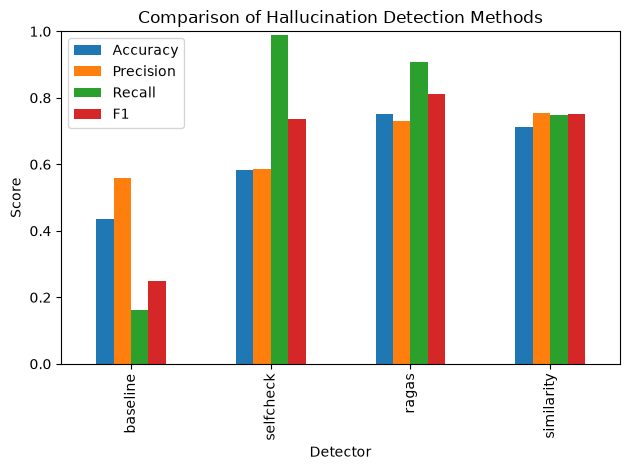

In [42]:
# Phase 2 — Plot Comparison Graph

import matplotlib.pyplot as plt

results.set_index("Detector").plot(kind="bar")

plt.title("Comparison of Hallucination Detection Methods")

plt.ylabel("Score")

plt.ylim(0,1)

plt.tight_layout()

plt.show()

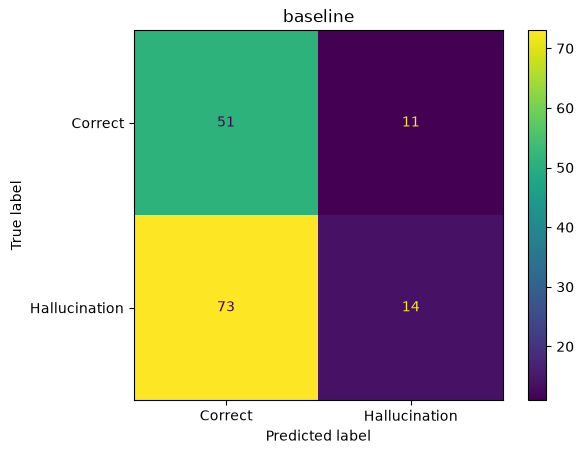

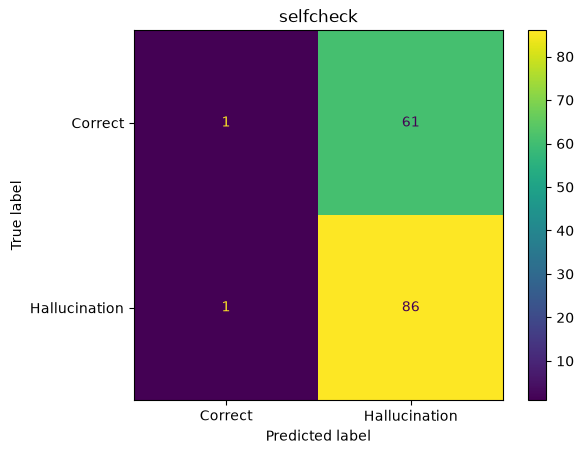

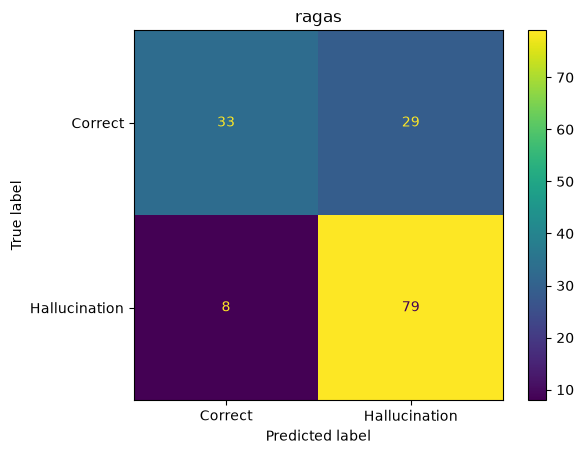

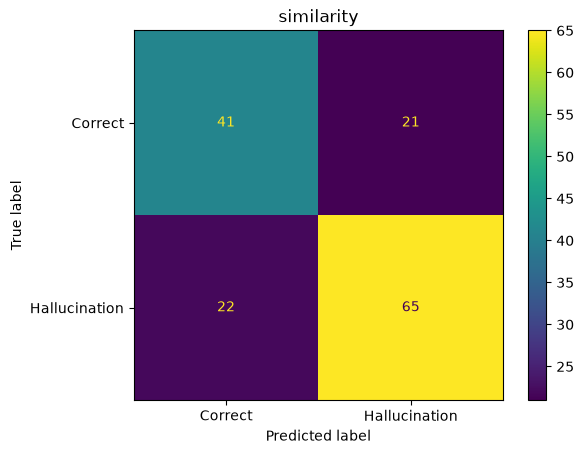

In [44]:
# Phase 3 — Confusion Matrices

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

for detector in detectors:

    cm = confusion_matrix(
        df["human"],
        df[detector]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Correct","Hallucination"]
    )

    disp.plot()

    plt.title(detector)

    plt.show()

In [45]:
# Phase 5 — Error Analysis (Very Important)

baseline_errors = df[df["human"] != df["baseline"]]

print(baseline_errors.head())

                                      id  human  baseline  selfcheck  ragas  \
1   b6eb09c5-ec36-4793-826b-7befb4aef0d1      1       0.0          1      1   
5   ea7c7bbf-25fe-450b-8681-8d04896498c1      1       0.0          1      1   
7   5075d8d5-505c-459f-a20e-d131423119d4      1       0.0          1      1   
8   a59aac82-c711-4356-af2f-1dcb0d48ab09      1       0.0          1      0   
10  c32b8a17-036a-47d1-a62d-4de76fe7ec81      1       0.0          1      1   

    similarity  
1            0  
5            1  
7            0  
8            1  
10           1  


In [46]:
ragas_errors = df[df["human"] != df["ragas"]]

print(ragas_errors.head())

                                      id  human  baseline  selfcheck  ragas  \
2   1b3a0e8e-2670-4d6b-8cb1-c3b8a02fc86a      1       1.0          1      0   
8   a59aac82-c711-4356-af2f-1dcb0d48ab09      1       0.0          1      0   
13  cb030ca1-6b86-4d94-b8d3-848ed8cc5ed5      0       0.0          1      1   
20  7363c602-09b7-407a-8510-0b039ed9f4f5      0       1.0          1      1   
23  41a546e8-5de5-4538-bb07-d1a70d0aba15      1       0.0          1      0   

    similarity  
2            0  
8            1  
13           1  
20           0  
23           1  
